# NB16: Bayesian Hierarchical Vigor Model (α, ρ)

Estimate tonic vigor (α) and phasic attack boost (ρ) using a hierarchical Bayesian model with **two optimized windows**.

**Model (two likelihoods, separate windows):**
```
pre_enc_rate_ij ~ Normal(α_i, σ_pre)                          # [enc − 2, enc]
terminal_rate_ij ~ Normal(γ_i + ρ_i · attack_ij, σ_term)      # [trialEnd − 2, trialEnd]
```

- α identified by pre-encounter approach pressing (tonic vigor, SB≈0.91)
- ρ identified by terminal attack contrast (phasic sprint, SB≈0.76 in v1)
- γ is a per-subject nuisance baseline for terminal non-attack rate

**Benefits:** Each window is optimized for its parameter. No forced coupling between α and ρ.

In [1]:
import numpy as np
import pandas as pd
import pickle
from pathlib import Path

import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, Predictive
import arviz as az
import matplotlib.pyplot as plt
from scipy import stats

numpyro.set_platform("cpu")
numpyro.set_host_device_count(4)

# Paths
ROOT = Path("../../")
DATA_DIR = ROOT / "data/exploratory_350/processed"
VIGOR_PREP = DATA_DIR / "vigor_prep"
STAGE2 = DATA_DIR / "stage2_trial_processing_20260317_094210"
RESULTS = ROOT / "results"
FIG_DIR = RESULTS / "figs"
STAT_DIR = RESULTS / "stats"

FIG_DIR.mkdir(parents=True, exist_ok=True)
STAT_DIR.mkdir(parents=True, exist_ok=True)

print(f"JAX: {jax.__version__}, NumPyro: {numpyro.__version__}, ArviZ: {az.__version__}")

/opt/anaconda3/envs/effort_foraging_threat/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


JAX: 0.9.1, NumPyro: 0.20.0, ArviZ: 0.23.4


## 1. Load data

In [2]:
# Keypresses (trial-start-relative times)
kp = pd.read_parquet(VIGOR_PREP / "keypress_events.parquet")

# Trial metadata with CORRECT encounter times from stage2
trials_raw = pickle.load(open(STAGE2 / "processed_trials.pkl", "rb"))

# Subject mapping (keypress file has integer subj IDs)
subj_map = kp[["participantID", "subj"]].drop_duplicates()
trials = trials_raw.merge(subj_map, on="participantID", how="inner")

# Keep relevant columns
trials = trials[["participantID", "subj", "trial", "threat", "choice",
                 "isAttackTrial", "encounterTime", "trialEndTime",
                 "firstEffortTime", "calibrationMax"]].copy()

print(f"Subjects: {trials['subj'].nunique()}")
print(f"Trials:   {len(trials)}")
print(f"Keypresses: {len(kp):,}")
print(f"\nEncounter times (trial-start-relative): {sorted(trials['encounterTime'].unique())}")
print(f"Attack rate: {trials['isAttackTrial'].mean():.2%}")

Subjects: 293
Trials:   23733
Keypresses: 899,936

Encounter times (trial-start-relative): [np.float64(2.5), np.float64(3.5), np.float64(5.0)]
Attack rate: 49.91%


## 2. Compute trial-level pressing rates

Count keypresses in two windows optimized for each parameter:
- **Pre-encounter** [enc − 2, enc]: tonic approach vigor → α
- **Terminal** [trialEnd − 2, trialEnd]: escape sprint → γ + ρ·attack

In [3]:
# Merge keypresses with trial timing
merged = kp.merge(
    trials[["participantID", "subj", "trial", "encounterTime", "trialEndTime"]],
    on=["participantID", "subj", "trial"]
)

# Pre-encounter window: [encounterTime - 2, encounterTime]
merged["in_pre_enc"] = (
    (merged["t"] >= merged["encounterTime"] - 2) &
    (merged["t"] <= merged["encounterTime"])
)

# Terminal window: [trialEndTime - 2, trialEndTime]
merged["in_terminal"] = (
    (merged["t"] >= merged["trialEndTime"] - 2) &
    (merged["t"] <= merged["trialEndTime"])
)

# Count per trial per window
pre_enc_counts = (merged[merged["in_pre_enc"]]
                  .groupby(["subj", "trial"]).size()
                  .reset_index(name="pre_enc_count"))
term_counts = (merged[merged["in_terminal"]]
               .groupby(["subj", "trial"]).size()
               .reset_index(name="term_count"))

# Merge back — fill missing with 0
trials = trials.merge(pre_enc_counts, on=["subj", "trial"], how="left")
trials = trials.merge(term_counts, on=["subj", "trial"], how="left")
trials["pre_enc_count"] = trials["pre_enc_count"].fillna(0).astype(int)
trials["term_count"] = trials["term_count"].fillna(0).astype(int)

# Rates (presses per second, 2s windows)
trials["pre_enc_rate"] = trials["pre_enc_count"] / 2.0
trials["term_rate"] = trials["term_count"] / 2.0

print(f"Pre-encounter rate:  mean={trials['pre_enc_rate'].mean():.2f}, sd={trials['pre_enc_rate'].std():.2f}")
print(f"Terminal rate:       mean={trials['term_rate'].mean():.2f}, sd={trials['term_rate'].std():.2f}")
print(f"\nTerminal rate by attack:")
print(trials.groupby("isAttackTrial")["term_rate"].describe()[["mean", "std"]])
print(f"\nPre-encounter rate by attack (should be similar):")
print(trials.groupby("isAttackTrial")["pre_enc_rate"].describe()[["mean", "std"]])

Pre-encounter rate:  mean=3.99, sd=2.68
Terminal rate:       mean=2.69, sd=3.03

Terminal rate by attack:
                   mean       std
isAttackTrial                    
0              0.686391  1.752149
1              4.700650  2.685952

Pre-encounter rate by attack (should be similar):
                   mean       std
isAttackTrial                    
0              4.113508  2.764918
1              3.872087  2.589082


## 3. Capacity normalization

Divide by each subject's 95th percentile of 1s-bin press rates to put everyone on a 0–1 scale.

In [4]:
# Compute capacity: 95th percentile of 1s-bin press rates per subject
kp_with_end = kp.merge(
    trials[["participantID", "subj", "trial", "trialEndTime"]],
    on=["participantID", "subj", "trial"]
)
kp_with_end["time_bin"] = kp_with_end["t"].astype(int)
bin_counts = (kp_with_end.groupby(["subj", "trial", "time_bin"])
              .size().reset_index(name="count"))
capacity = (bin_counts.groupby("subj")["count"]
            .quantile(0.95).reset_index(name="capacity"))

trials = trials.merge(capacity, on="subj", how="left")

# Normalize both windows
trials["pre_enc_rate_norm"] = trials["pre_enc_rate"] / trials["capacity"]
trials["term_rate_norm"] = trials["term_rate"] / trials["capacity"]

print(f"Capacity: mean={capacity['capacity'].mean():.1f}, range=[{capacity['capacity'].min():.0f}, {capacity['capacity'].max():.0f}]")
print(f"\nNorm pre-enc:  mean={trials['pre_enc_rate_norm'].mean():.3f}, sd={trials['pre_enc_rate_norm'].std():.3f}")
print(f"Norm terminal: mean={trials['term_rate_norm'].mean():.3f}, sd={trials['term_rate_norm'].std():.3f}")
print(f"\nTerminal by attack:")
print(trials.groupby("isAttackTrial")["term_rate_norm"].agg(["mean", "std"]).round(3))

Capacity: mean=7.7, range=[4, 16]

Norm pre-enc:  mean=0.517, sd=0.326
Norm terminal: mean=0.350, sd=0.383

Terminal by attack:
                mean    std
isAttackTrial              
0              0.091  0.231
1              0.609  0.326


## 4. Prepare model arrays

In [5]:
# Exclude: trials with no presses or zero capacity
model_data = trials.dropna(subset=["firstEffortTime"]).copy()
model_data = model_data[model_data["capacity"] > 0].copy()

# Integer subject index (0-based, contiguous)
subj_ids = sorted(model_data["subj"].unique())
subj_to_idx = {s: i for i, s in enumerate(subj_ids)}
model_data["subj_idx"] = model_data["subj"].map(subj_to_idx)

n_subj = len(subj_ids)
n_obs = len(model_data)

# JAX arrays
subj_idx_jax = jnp.array(model_data["subj_idx"].values)
attack_jax = jnp.array(model_data["isAttackTrial"].values, dtype=jnp.float32)
rate_pre_jax = jnp.array(model_data["pre_enc_rate_norm"].values, dtype=jnp.float32)
rate_term_jax = jnp.array(model_data["term_rate_norm"].values, dtype=jnp.float32)

print(f"Model data: {n_subj} subjects, {n_obs:,} trials")
print(f"  Attack: {int(attack_jax.sum()):,}  |  Non-attack: {int((attack_jax == 0).sum()):,}")
print(f"  Pre-enc rate range:  [{float(rate_pre_jax.min()):.3f}, {float(rate_pre_jax.max()):.3f}]")
print(f"  Terminal rate range: [{float(rate_term_jax.min()):.3f}, {float(rate_term_jax.max()):.3f}]")

Model data: 293 subjects, 23,556 trials


  Attack: 11,700  |  Non-attack: 11,856
  Pre-enc rate range:  [0.000, 9.000]
  Terminal rate range: [0.000, 8.833]


## 5. Model definition

Two separate windows, each optimized for its parameter. γ_i is a nuisance per-subject terminal baseline.

In [6]:
def vigor_model(subj_idx, attack, rate_pre=None, rate_term=None, n_subj=293):
    """
    Two-window hierarchical Bayesian vigor model.
    
    pre_enc_rate_ij  ~ Normal(α_i, σ_pre)
    terminal_rate_ij ~ Normal(γ_i + ρ_i * attack_ij, σ_term)
    
    α_i = tonic vigor from pre-encounter window [enc-2, enc]
    ρ_i = phasic vigor (attack boost) from terminal window [trialEnd-2, trialEnd]
    γ_i = nuisance terminal baseline (non-attack rate)
    """
    # --- α: tonic vigor ---
    mu_alpha = numpyro.sample("mu_alpha", dist.Normal(0.5, 0.5))
    sigma_alpha = numpyro.sample("sigma_alpha", dist.HalfNormal(0.3))
    
    # --- γ: terminal baseline (nuisance) ---
    mu_gamma = numpyro.sample("mu_gamma", dist.Normal(0.1, 0.5))
    sigma_gamma = numpyro.sample("sigma_gamma", dist.HalfNormal(0.3))
    
    # --- ρ: attack boost ---
    mu_rho = numpyro.sample("mu_rho", dist.Normal(0.0, 0.3))
    sigma_rho = numpyro.sample("sigma_rho", dist.HalfNormal(0.3))
    
    # --- Subject-level (non-centered) ---
    with numpyro.plate("subjects", n_subj):
        alpha_z = numpyro.sample("alpha_z", dist.Normal(0, 1))
        gamma_z = numpyro.sample("gamma_z", dist.Normal(0, 1))
        rho_z = numpyro.sample("rho_z", dist.Normal(0, 1))
    
    alpha = numpyro.deterministic("alpha", mu_alpha + sigma_alpha * alpha_z)
    gamma = mu_gamma + sigma_gamma * gamma_z  # not tracked (nuisance)
    rho = numpyro.deterministic("rho", mu_rho + sigma_rho * rho_z)
    
    # --- Observation noise ---
    sigma_pre = numpyro.sample("sigma_pre", dist.HalfNormal(0.5))
    sigma_term = numpyro.sample("sigma_term", dist.HalfNormal(0.5))
    
    # --- Pre-encounter likelihood: α only ---
    numpyro.sample("obs_pre", dist.Normal(alpha[subj_idx], sigma_pre), obs=rate_pre)
    
    # --- Terminal likelihood: γ + ρ * attack ---
    mu_t = gamma[subj_idx] + rho[subj_idx] * attack
    numpyro.sample("obs_term", dist.Normal(mu_t, sigma_term), obs=rate_term)

# Prior predictive check
prior_pred = Predictive(vigor_model, num_samples=500)
prior_samples = prior_pred(jax.random.PRNGKey(0), subj_idx=subj_idx_jax,
                           attack=attack_jax, n_subj=n_subj)

print("Prior predictive check:")
print(f"  alpha range: [{float(prior_samples['alpha'].min()):.2f}, {float(prior_samples['alpha'].max()):.2f}]")
print(f"  rho range:   [{float(prior_samples['rho'].min()):.2f}, {float(prior_samples['rho'].max()):.2f}]")
print(f"  Pre data:    [{float(rate_pre_jax.min()):.2f}, {float(rate_pre_jax.max()):.2f}]")
print(f"  Term data:   [{float(rate_term_jax.min()):.2f}, {float(rate_term_jax.max()):.2f}]")

W0320 11:56:08.313269 120235729 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


Prior predictive check:


  alpha range: [-2.61, 3.51]
  rho range:   [-3.70, 3.10]
  Pre data:    [0.00, 9.00]
  Term data:   [0.00, 8.83]


## 6. Run MCMC

4 chains × 1000 warmup + 1000 samples, NUTS with target_accept=0.9.

In [7]:
%%time

kernel = NUTS(vigor_model, target_accept_prob=0.9)
mcmc = MCMC(kernel, num_warmup=1000, num_samples=1000, num_chains=4)

rng_key = jax.random.PRNGKey(42)
mcmc.run(rng_key, subj_idx=subj_idx_jax, attack=attack_jax,
         rate_pre=rate_pre_jax, rate_term=rate_term_jax, n_subj=n_subj)

mcmc.print_summary(exclude_deterministic=True)

  0%|          | 0/2000 [00:00<?, ?it/s]

Compiling.. :   0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

Compiling.. :   0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

...

Running chain 2: 100%|██████████| 2000/2000 [00:56<00:00, 89.76it/s]

Running chain 2: 100%|██████████| 2000/2000 [00:56<00:00, 35.24it/s]

Running chain 0: 100%|██████████| 2000/2000 [00:57<00:00, 90.61it/s]

Running chain 0: 100%|██████████| 2000/2000 [00:57<00:00, 34.75it/s]


                   mean       std    median      5.0%     95.0%     n_eff     r_hat
   alpha_z[0]      1.05      0.16      1.05      0.80      1.33    634.35      1.01
   alpha_z[1]      0.76      0.15      0.75      0.51      1.02    991.86      1.00
   alpha_z[2]     -0.91      0.16     -0.91     -1.18     -0.66    810.08      1.00
   alpha_z[3]      1.41      0.17      1.41      1.15      1.70    614.78      1.01
   alpha_z[4]     -1.41      0.17     -1.41     -1.68     -1.13    806.25      1.00
   alpha_z[5]      0.52      0.16      0.52      0.26      0.78    977.13      1.01
   alpha_z[6]      0.63      0.16      0.63      0.36      0.88    885.28      1.01
   alpha_z[7]     -0.19      0.15     -0.19     -0.46      0.04    932.23      1.00
   alpha_z[8]     -1.22      0.16     -1.22     -1.48     -0.94    810.12      1.01
   alpha_z[9]     -0.10      0.16     -0.10     -0.36      0.17    960.01      1.01
  alpha_z[10]     -0.45      0.16     -0.45     -0.72     -0.20    774.71  

## 7. Convergence diagnostics

In [8]:
idata = az.from_numpyro(mcmc)

# Population-level summary
pop_params = ["mu_alpha", "mu_gamma", "mu_rho", "sigma_alpha", "sigma_gamma",
              "sigma_rho", "sigma_pre", "sigma_term"]
pop_summary = az.summary(idata, var_names=pop_params)
print("=== Population parameters ===")
print(pop_summary.round(4))

# Check Rhat for subject-level
all_rhat = az.rhat(idata)
max_rhat_alpha = float(all_rhat["alpha"].max())
max_rhat_rho = float(all_rhat["rho"].max())
print(f"\nMax Rhat across subjects: alpha={max_rhat_alpha:.3f}, rho={max_rhat_rho:.3f}")

# Divergences
n_div = int(idata.sample_stats["diverging"].sum())
print(f"Divergent transitions: {n_div} / {4*1000}")

=== Population parameters ===
              mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
mu_alpha     0.519  0.011   0.500    0.542      0.001      0.0     122.0   
mu_gamma     0.092  0.005   0.082    0.101      0.000      0.0    1171.0   
mu_rho       0.526  0.009   0.510    0.542      0.000      0.0     558.0   
sigma_alpha  0.196  0.008   0.181    0.212      0.001      0.0     245.0   
sigma_gamma  0.074  0.004   0.066    0.081      0.000      0.0    1392.0   
sigma_rho    0.129  0.006   0.117    0.141      0.000      0.0    1077.0   
sigma_pre    0.260  0.001   0.258    0.262      0.000      0.0    9916.0   
sigma_term   0.256  0.001   0.253    0.258      0.000      0.0    8800.0   

             ess_tail  r_hat  
mu_alpha        252.0   1.05  
mu_gamma       1848.0   1.01  
mu_rho          926.0   1.01  
sigma_alpha     374.0   1.02  
sigma_gamma    1716.0   1.00  
sigma_rho      1900.0   1.01  
sigma_pre      3181.0   1.00  
sigma_term     2940.0   1.00  



Max Rhat across subjects: alpha=1.006, rho=1.003
Divergent transitions: 0 / 4000


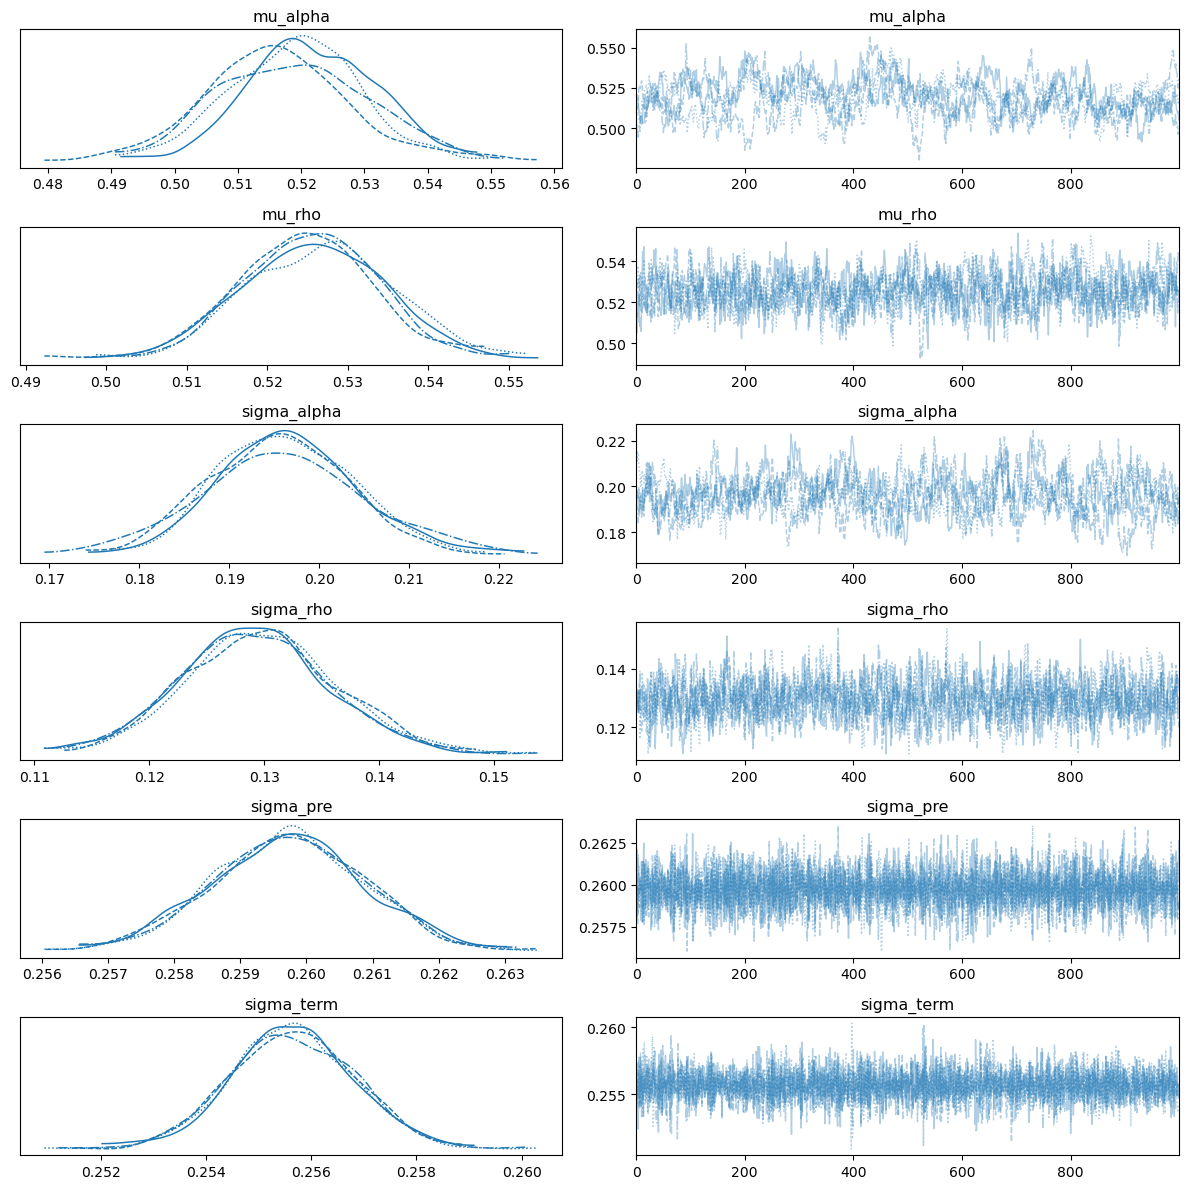

In [9]:
# Traceplots for key population parameters
key_params = ["mu_alpha", "mu_rho", "sigma_alpha", "sigma_rho", "sigma_pre", "sigma_term"]
fig, axes = plt.subplots(6, 2, figsize=(12, 12))
az.plot_trace(idata, var_names=key_params, axes=axes)
plt.tight_layout()
plt.savefig(FIG_DIR / "vigor_hbm_traceplots.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Population-level results

Key question: Is μ_ρ > 0? (formal test that the group-level sprint effect is nonzero)

=== Group-level sprint effect (μ_ρ) ===
  Posterior mean:  0.5256
  Posterior SD:    0.0086
  95% HDI:         [0.5088, 0.5423]
  P(μ_ρ > 0):     1.0000

=== Group-level tonic rate (μ_α) ===
  Posterior mean:  0.5189
  95% HDI:         [0.4969, 0.5410]

=== Between-subject SDs ===
  σ_α: 0.1962
  σ_ρ: 0.1294
  Ratio σ_α/σ_ρ: 1.52


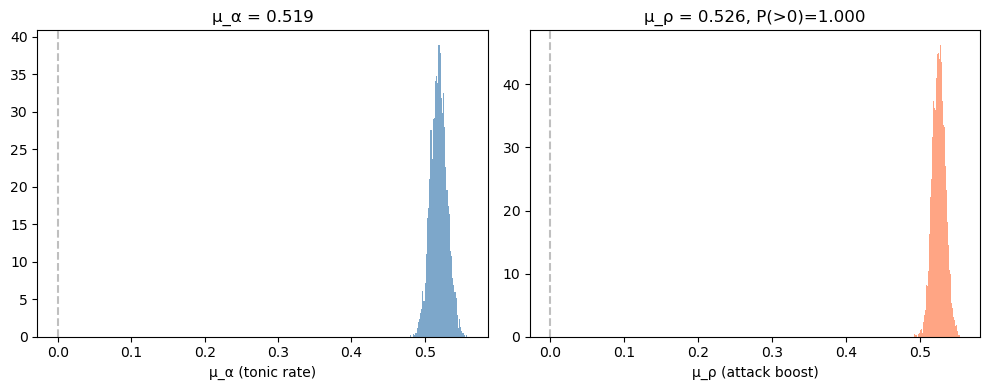

In [10]:
posterior = mcmc.get_samples()

# Population-level sprint effect
mu_rho_samples = np.array(posterior["mu_rho"])
prob_rho_pos = (mu_rho_samples > 0).mean()
hdi_rho = az.hdi(mu_rho_samples, hdi_prob=0.95)

print("=== Group-level sprint effect (μ_ρ) ===")
print(f"  Posterior mean:  {mu_rho_samples.mean():.4f}")
print(f"  Posterior SD:    {mu_rho_samples.std():.4f}")
print(f"  95% HDI:         [{hdi_rho[0]:.4f}, {hdi_rho[1]:.4f}]")
print(f"  P(μ_ρ > 0):     {prob_rho_pos:.4f}")
print()

# Population-level tonic rate
mu_alpha_samples = np.array(posterior["mu_alpha"])
hdi_alpha = az.hdi(mu_alpha_samples, hdi_prob=0.95)
print("=== Group-level tonic rate (μ_α) ===")
print(f"  Posterior mean:  {mu_alpha_samples.mean():.4f}")
print(f"  95% HDI:         [{hdi_alpha[0]:.4f}, {hdi_alpha[1]:.4f}]")
print()

# Between-subject variability
print("=== Between-subject SDs ===")
print(f"  σ_α: {np.array(posterior['sigma_alpha']).mean():.4f}")
print(f"  σ_ρ: {np.array(posterior['sigma_rho']).mean():.4f}")
print(f"  Ratio σ_α/σ_ρ: {np.array(posterior['sigma_alpha']).mean() / np.array(posterior['sigma_rho']).mean():.2f}")

# Posterior predictive summary
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(mu_alpha_samples, bins=50, density=True, alpha=0.7, color="steelblue")
axes[0].axvline(0, ls="--", color="gray", alpha=0.5)
axes[0].set_title(f"μ_α = {mu_alpha_samples.mean():.3f}")
axes[0].set_xlabel("μ_α (tonic rate)")

axes[1].hist(mu_rho_samples, bins=50, density=True, alpha=0.7, color="coral")
axes[1].axvline(0, ls="--", color="gray", alpha=0.5)
axes[1].set_title(f"μ_ρ = {mu_rho_samples.mean():.3f}, P(>0)={prob_rho_pos:.3f}")
axes[1].set_xlabel("μ_ρ (attack boost)")

plt.tight_layout()
plt.savefig(FIG_DIR / "vigor_hbm_population.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Subject-level posteriors & shrinkage

Bayesian vs OLS: α r=1.000, ρ r=0.991


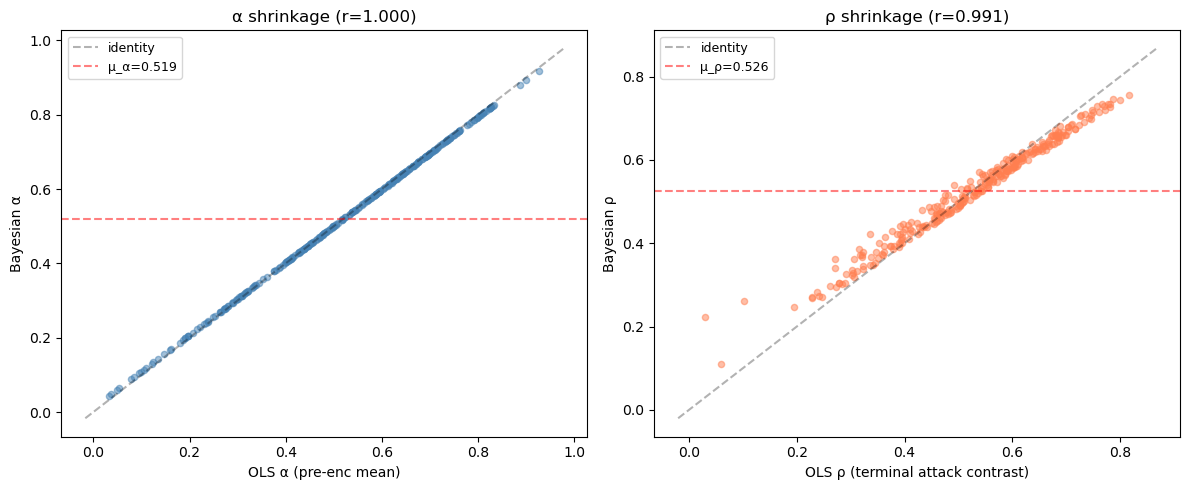


Shrinkage (1 - SD_bayes/SD_ols): α=2.15%, ρ=16.81%


In [11]:
alpha_post_samples = np.array(posterior["alpha"])   # (n_samples, n_subj)
rho_post_samples = np.array(posterior["rho"])

# Posterior means and SDs
alpha_mean = alpha_post_samples.mean(axis=0)
alpha_sd = alpha_post_samples.std(axis=0)
rho_mean = rho_post_samples.mean(axis=0)
rho_sd = rho_post_samples.std(axis=0)

# OLS estimates
# α OLS = mean pre-encounter rate per subject
ols_alpha = model_data.groupby("subj_idx")["pre_enc_rate_norm"].mean().reindex(range(n_subj)).values
# ρ OLS = terminal attack rate - terminal non-attack rate per subject
ols_term_attack = model_data[model_data["isAttackTrial"] == 1].groupby("subj_idx")["term_rate_norm"].mean()
ols_term_noattack = model_data[model_data["isAttackTrial"] == 0].groupby("subj_idx")["term_rate_norm"].mean()
ols_rho = (ols_term_attack - ols_term_noattack).reindex(range(n_subj)).values

# Subject summary table
subj_summary = pd.DataFrame({
    "subj": subj_ids,
    "alpha_bayes": alpha_mean,
    "alpha_sd": alpha_sd,
    "rho_bayes": rho_mean,
    "rho_sd": rho_sd,
    "alpha_ols": ols_alpha,
    "rho_ols": ols_rho,
})

# Bayesian-OLS correlations
r_alpha = np.corrcoef(subj_summary["alpha_bayes"], subj_summary["alpha_ols"])[0, 1]
r_rho = np.corrcoef(subj_summary["rho_bayes"], subj_summary["rho_ols"])[0, 1]
print(f"Bayesian vs OLS: α r={r_alpha:.3f}, ρ r={r_rho:.3f}")

# Shrinkage plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
mu_a = float(np.array(posterior["mu_alpha"]).mean())
mu_r = float(np.array(posterior["mu_rho"]).mean())

ax = axes[0]
ax.scatter(ols_alpha, alpha_mean, alpha=0.5, s=20, c="steelblue")
lim = [min(ols_alpha.min(), alpha_mean.min()) - 0.05,
       max(ols_alpha.max(), alpha_mean.max()) + 0.05]
ax.plot(lim, lim, "k--", alpha=0.3, label="identity")
ax.axhline(mu_a, color="red", ls="--", alpha=0.5, label=f"μ_α={mu_a:.3f}")
ax.set(xlabel="OLS α (pre-enc mean)", ylabel="Bayesian α",
       title=f"α shrinkage (r={r_alpha:.3f})")
ax.legend(fontsize=9)

ax = axes[1]
ax.scatter(ols_rho, rho_mean, alpha=0.5, s=20, c="coral")
lim_r = [min(ols_rho.min(), rho_mean.min()) - 0.05,
         max(ols_rho.max(), rho_mean.max()) + 0.05]
ax.plot(lim_r, lim_r, "k--", alpha=0.3, label="identity")
ax.axhline(mu_r, color="red", ls="--", alpha=0.5, label=f"μ_ρ={mu_r:.3f}")
ax.set(xlabel="OLS ρ (terminal attack contrast)", ylabel="Bayesian ρ",
       title=f"ρ shrinkage (r={r_rho:.3f})")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / "vigor_hbm_shrinkage.png", dpi=150, bbox_inches="tight")
plt.show()

shrink_alpha = 1 - np.std(alpha_mean) / np.std(ols_alpha)
shrink_rho = 1 - np.std(rho_mean) / np.std(ols_rho)
print(f"\nShrinkage (1 - SD_bayes/SD_ols): α={shrink_alpha:.2%}, ρ={shrink_rho:.2%}")

## 10. Validation

- α (Bayesian) should correlate strongly with OLS pre-encounter rate (it's estimated from same data)
- α and ρ should be uncorrelated (independence of tonic and phasic)
- Split-half reliability of both α and ρ

α-ρ correlation: r=-0.237, p=0.000
ρ OLS split-half: r=0.616, Spearman-Brown=0.762
α OLS split-half: r=0.861, Spearman-Brown=0.925


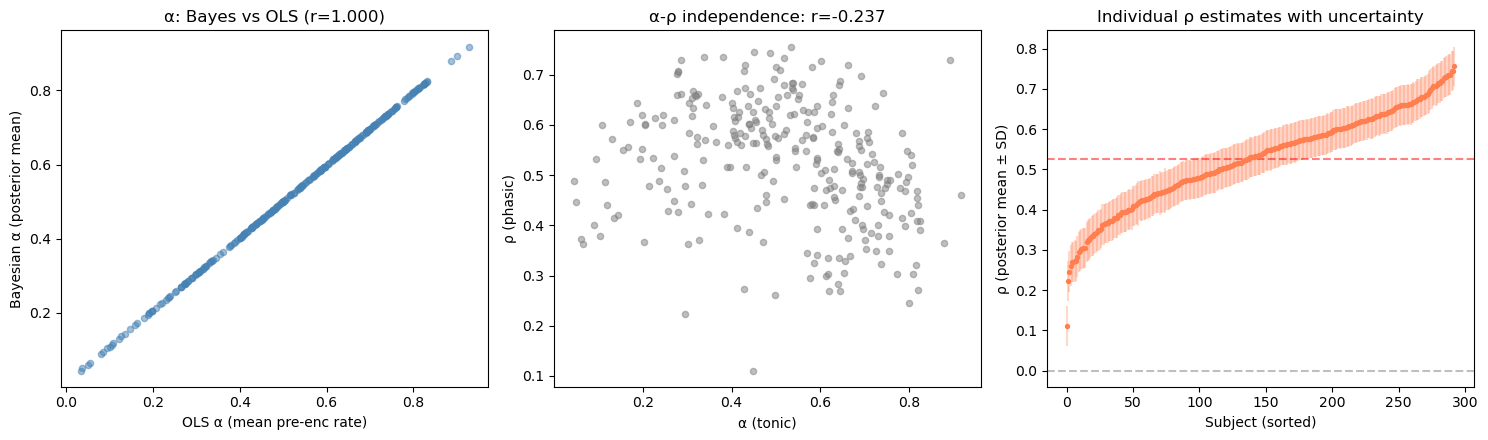

In [12]:
# α-ρ independence
r_ar, p_ar = stats.pearsonr(subj_summary["alpha_bayes"], subj_summary["rho_bayes"])
print(f"α-ρ correlation: r={r_ar:.3f}, p={p_ar:.3f}")

# OLS split-half reliability for ρ (terminal attack contrast)
odd_data = model_data[model_data["trial"] % 2 == 1]
even_data = model_data[model_data["trial"] % 2 == 0]

rho_odd = (odd_data[odd_data["isAttackTrial"] == 1].groupby("subj_idx")["term_rate_norm"].mean()
           - odd_data[odd_data["isAttackTrial"] == 0].groupby("subj_idx")["term_rate_norm"].mean())
rho_even = (even_data[even_data["isAttackTrial"] == 1].groupby("subj_idx")["term_rate_norm"].mean()
            - even_data[even_data["isAttackTrial"] == 0].groupby("subj_idx")["term_rate_norm"].mean())

rho_sh = pd.DataFrame({"odd": rho_odd, "even": rho_even}).dropna()
r_sh = np.corrcoef(rho_sh["odd"], rho_sh["even"])[0, 1]
sb_rho = 2 * r_sh / (1 + r_sh)
print(f"ρ OLS split-half: r={r_sh:.3f}, Spearman-Brown={sb_rho:.3f}")

# Split-half for α (pre-enc rate)
alpha_odd = odd_data.groupby("subj_idx")["pre_enc_rate_norm"].mean()
alpha_even = even_data.groupby("subj_idx")["pre_enc_rate_norm"].mean()
alpha_sh = pd.DataFrame({"odd": alpha_odd, "even": alpha_even}).dropna()
r_sh_a = np.corrcoef(alpha_sh["odd"], alpha_sh["even"])[0, 1]
sb_alpha = 2 * r_sh_a / (1 + r_sh_a)
print(f"α OLS split-half: r={r_sh_a:.3f}, Spearman-Brown={sb_alpha:.3f}")

# Plots
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ax = axes[0]
ax.scatter(subj_summary["alpha_ols"], subj_summary["alpha_bayes"],
           alpha=0.5, s=20, c="steelblue")
ax.set(xlabel="OLS α (mean pre-enc rate)",
       ylabel="Bayesian α (posterior mean)",
       title=f"α: Bayes vs OLS (r={r_alpha:.3f})")

ax = axes[1]
ax.scatter(subj_summary["alpha_bayes"], subj_summary["rho_bayes"],
           alpha=0.5, s=20, c="gray")
ax.set(xlabel="α (tonic)", ylabel="ρ (phasic)",
       title=f"α-ρ independence: r={r_ar:.3f}")

ax = axes[2]
ax.errorbar(range(n_subj), rho_mean[np.argsort(rho_mean)],
            yerr=rho_sd[np.argsort(rho_mean)], fmt="none",
            ecolor="coral", alpha=0.3, capsize=0)
ax.scatter(range(n_subj), rho_mean[np.argsort(rho_mean)],
           s=8, c="coral", zorder=5)
ax.axhline(0, ls="--", color="gray", alpha=0.5)
ax.axhline(mu_r, ls="--", color="red", alpha=0.5)
ax.set(xlabel="Subject (sorted)", ylabel="ρ (posterior mean ± SD)",
       title="Individual ρ estimates with uncertainty")

plt.tight_layout()
plt.savefig(FIG_DIR / "vigor_hbm_validation.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Posterior predictive check

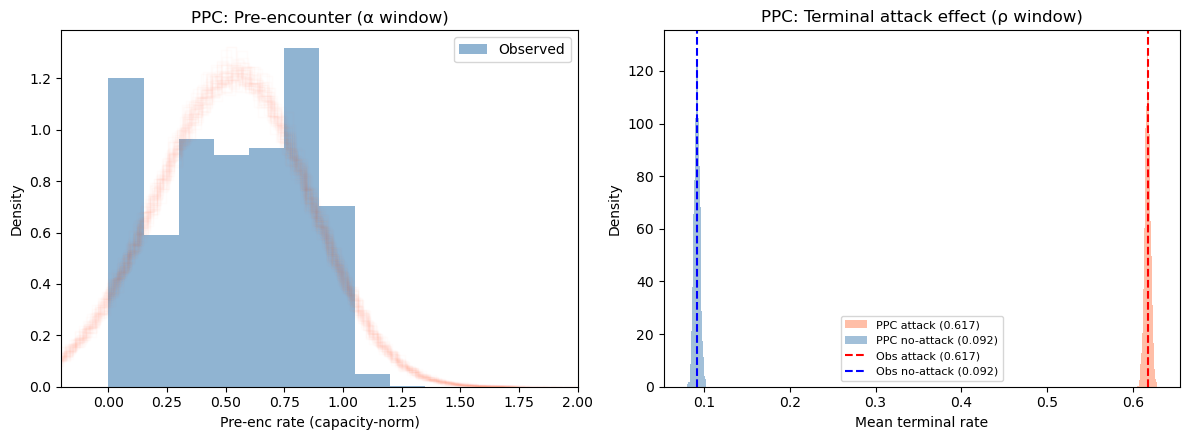

In [13]:
# Posterior predictive check
pred = Predictive(vigor_model, posterior_samples=posterior)
ppc = pred(jax.random.PRNGKey(99), subj_idx=subj_idx_jax,
           attack=attack_jax, n_subj=n_subj)

ppc_pre = np.array(ppc["obs_pre"])
ppc_term = np.array(ppc["obs_term"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Pre-encounter PPC
ax = axes[0]
ax.hist(np.array(rate_pre_jax), bins=60, density=True, alpha=0.6,
        color="steelblue", label="Observed")
for i in range(50):
    ax.hist(ppc_pre[i], bins=60, density=True, alpha=0.02,
            color="coral", histtype="step")
ax.set(xlabel="Pre-enc rate (capacity-norm)", ylabel="Density",
       title="PPC: Pre-encounter (α window)", xlim=(-0.2, 2.0))
ax.legend()

# Terminal: attack vs non-attack recovery
attack_mask = np.array(attack_jax) == 1
ppc_term_attack = ppc_term[:, attack_mask].mean(axis=1)
ppc_term_noattack = ppc_term[:, ~attack_mask].mean(axis=1)
obs_term_attack = float(np.array(rate_term_jax)[attack_mask].mean())
obs_term_noattack = float(np.array(rate_term_jax)[~attack_mask].mean())

ax = axes[1]
ax.hist(ppc_term_attack, bins=40, alpha=0.5, color="coral",
        label=f"PPC attack ({ppc_term_attack.mean():.3f})", density=True)
ax.hist(ppc_term_noattack, bins=40, alpha=0.5, color="steelblue",
        label=f"PPC no-attack ({ppc_term_noattack.mean():.3f})", density=True)
ax.axvline(obs_term_attack, color="red", ls="--",
           label=f"Obs attack ({obs_term_attack:.3f})")
ax.axvline(obs_term_noattack, color="blue", ls="--",
           label=f"Obs no-attack ({obs_term_noattack:.3f})")
ax.set(xlabel="Mean terminal rate", ylabel="Density",
       title="PPC: Terminal attack effect (ρ window)")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "vigor_hbm_ppc.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# Load choice parameters from FET model
k_df = pd.read_csv(RESULTS / "stats" / "FET_Exp_Bias_k_params.csv")
z_df = pd.read_csv(RESULTS / "stats" / "FET_Exp_Bias_z_params.csv")
beta_df = pd.read_csv(RESULTS / "stats" / "FET_Exp_Bias_beta_params.csv")

# Merge choice params with vigor posteriors (subject = subj, both 1-293)
subj_summary["k"] = k_df.set_index("subject")["mean"].reindex(subj_summary["subj"]).values
subj_summary["z"] = z_df.set_index("subject")["mean"].reindex(subj_summary["subj"]).values
subj_summary["beta"] = beta_df.set_index("subject")["mean"].reindex(subj_summary["subj"]).values

# 5-parameter correlation matrix
params_5 = subj_summary[["k", "z", "beta", "alpha_bayes", "rho_bayes"]].rename(
    columns={"alpha_bayes": "α", "rho_bayes": "ρ", "beta": "β"})

print("=== 5-parameter correlation matrix ===")
corr = params_5.corr().round(3)
print(corr)

# Key dissociation checks
r_k_alpha, p_k_alpha = stats.pearsonr(subj_summary["k"], subj_summary["alpha_bayes"])
r_beta_alpha, p_beta_alpha = stats.pearsonr(subj_summary["beta"], subj_summary["alpha_bayes"])
r_k_rho, p_k_rho = stats.pearsonr(subj_summary["k"], subj_summary["rho_bayes"])
r_beta_rho, p_beta_rho = stats.pearsonr(subj_summary["beta"], subj_summary["rho_bayes"])

print(f"\nChoice-vigor cross-correlations (Bayesian estimates):")
print(f"  k-α:  r={r_k_alpha:.3f}, p={p_k_alpha:.3f}")
print(f"  k-ρ:  r={r_k_rho:.3f}, p={p_k_rho:.3f}")
print(f"  β-α:  r={r_beta_alpha:.3f}, p={p_beta_alpha:.3f}")
print(f"  β-ρ:  r={r_beta_rho:.3f}, p={p_beta_rho:.3f}")

=== 5-parameter correlation matrix ===
       k      z      β      α      ρ
k  1.000  0.184  0.139 -0.196 -0.033
z  0.184  1.000  0.057  0.163 -0.105
β  0.139  0.057  1.000  0.092 -0.010
α -0.196  0.163  0.092  1.000 -0.237
ρ -0.033 -0.105 -0.010 -0.237  1.000

Choice-vigor cross-correlations (Bayesian estimates):
  k-α:  r=-0.196, p=0.001
  k-ρ:  r=-0.033, p=0.577
  β-α:  r=0.092, p=0.114
  β-ρ:  r=-0.010, p=0.863


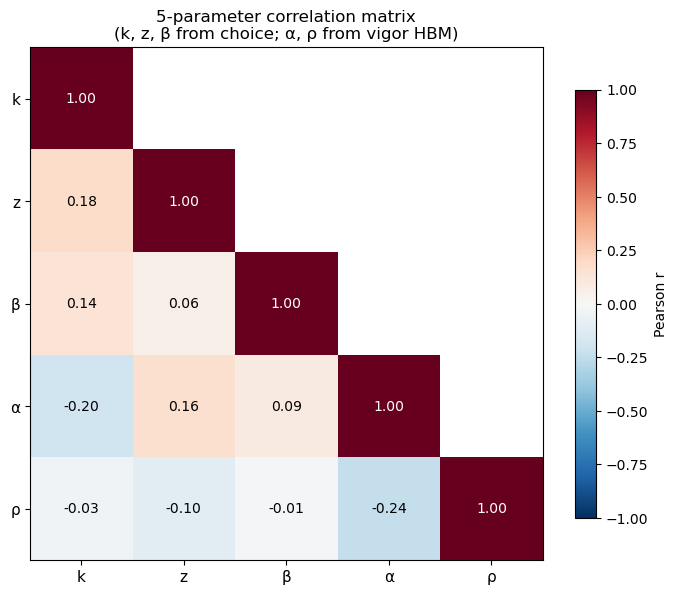

In [15]:
# Correlation heatmap for 5 parameters
fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
im = ax.imshow(corr.where(~mask).values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="equal")

labels = corr.columns.tolist()
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=11)
ax.set_yticklabels(labels, fontsize=11)

# Annotate
for i in range(len(labels)):
    for j in range(len(labels)):
        if not mask[i, j]:
            val = corr.iloc[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=10, color="white" if abs(val) > 0.5 else "black")

plt.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
ax.set_title("5-parameter correlation matrix\n(k, z, β from choice; α, ρ from vigor HBM)")
plt.tight_layout()
plt.savefig(FIG_DIR / "vigor_hbm_5param_corr.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Save results

In [16]:
# Save subject-level posteriors
subj_summary.to_csv(STAT_DIR / "vigor_hbm_posteriors.csv", index=False)
print(f"Saved: {STAT_DIR / 'vigor_hbm_posteriors.csv'}")
print(f"  Columns: {subj_summary.columns.tolist()}")

# Save population-level summary
pop_results = {
    "mu_alpha_mean": float(mu_alpha_samples.mean()),
    "mu_alpha_hdi_lo": float(hdi_alpha[0]),
    "mu_alpha_hdi_hi": float(hdi_alpha[1]),
    "mu_rho_mean": float(mu_rho_samples.mean()),
    "mu_rho_hdi_lo": float(hdi_rho[0]),
    "mu_rho_hdi_hi": float(hdi_rho[1]),
    "p_rho_pos": float(prob_rho_pos),
    "sigma_alpha": float(np.array(posterior["sigma_alpha"]).mean()),
    "sigma_gamma": float(np.array(posterior["sigma_gamma"]).mean()),
    "sigma_rho": float(np.array(posterior["sigma_rho"]).mean()),
    "sigma_pre": float(np.array(posterior["sigma_pre"]).mean()),
    "sigma_term": float(np.array(posterior["sigma_term"]).mean()),
    "n_subj": n_subj,
    "n_obs": n_obs,
    "n_divergent": n_div,
    "max_rhat_alpha": max_rhat_alpha,
    "max_rhat_rho": max_rhat_rho,
}
pd.DataFrame([pop_results]).to_csv(STAT_DIR / "vigor_hbm_population.csv", index=False)
print(f"Saved: {STAT_DIR / 'vigor_hbm_population.csv'}")

# Save MCMC trace as NetCDF
idata.to_netcdf(str(RESULTS / "model_fits" / "exploratory" / "vigor_hbm_idata.nc"))
print(f"Saved: {RESULTS / 'model_fits' / 'exploratory' / 'vigor_hbm_idata.nc'}")

print("\nDone!")

Saved: ../../results/stats/vigor_hbm_posteriors.csv
  Columns: ['subj', 'alpha_bayes', 'alpha_sd', 'rho_bayes', 'rho_sd', 'alpha_ols', 'rho_ols', 'k', 'z', 'beta']
Saved: ../../results/stats/vigor_hbm_population.csv


Saved: ../../results/model_fits/exploratory/vigor_hbm_idata.nc

Done!
